Neural Networks for Handwritten Digit Recognition, `Multiclass` 

In [111]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt


## 3 - Softmax Function
A multiclass neural network generates N outputs. One output is selected as the predicted answer. In the output layer, a vector $\mathbf{z}$ is generated by a `linear function` which is fed into a softmax function. The softmax function converts $\mathbf{z}$  into a probability distribution as described below. After applying softmax, each output will be between 0 and 1 and the outputs will sum to 1. They can be interpreted as probabilities. The larger inputs to the softmax will correspond to larger output probabilities.

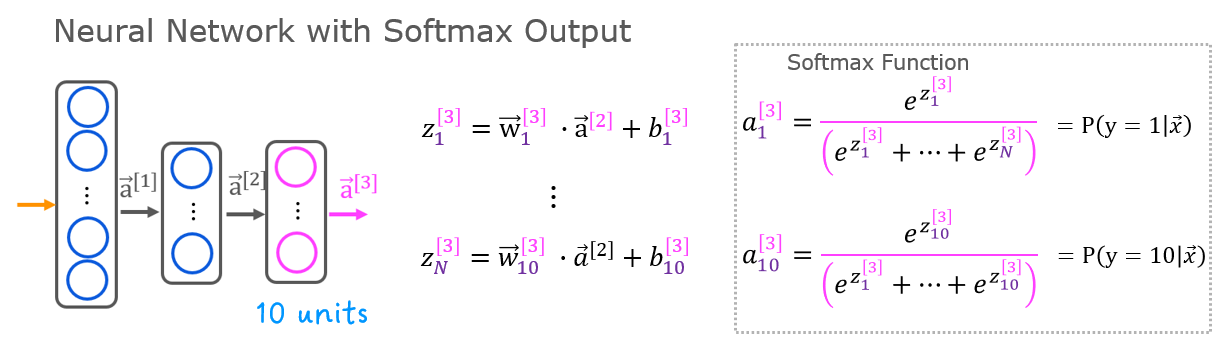


The softmax function can be written:
$$a_j = \frac{e^{z_j}}{ \sum_{k=0}^{N-1}{e^{z_k} }} \tag{1}$$

Where $z = \mathbf{w} \cdot \mathbf{x} + b$ and N is the number of feature/categories in the output layer.  

In [112]:
def my_softmax(z):
    z = z - np.max(z,keepdims=True)   
    ez = np.exp(z)
    return ez / np.sum(ez, axis=-1, keepdims=True)

# Example

In [113]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
print(f"our softmax = {a}")


atf = tf.nn.softmax(z)
print(f"Tensor flow softmax = {atf}")


our softmax = [0.0320586  0.08714432 0.23688282 0.64391426]
Tensor flow softmax = [0.0320586  0.08714432 0.23688282 0.64391426]


## Goal: Building a neural network to classify digits 0-9
## Dataset
- The data set contains 5000 training examples of handwritten digits
- Each training example is a 20-pixel x 20-pixel
- Each pixel is represented by a floating-point number indicating the grayscale intensity at that location
- The 20 by 20 grid of pixels is “unrolled” into a 400-dimensional vector
- Each training examples becomes a single row in our data matrix `X`
- This gives us a 5000 x 400 matrix `X` where every row is a training example of a handwritten digit image.

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$


- The second part of the training set is a 5000 x 1 dimensional vector `y` that contains labels for the training set
    - `y = 0` if the image is of the digit `0`, `y = 4` if the image is of the digit `4` and so on.

In [114]:
from UTL import load_data
X,y = load_data()

In [115]:
print (f'The shape of X is: {X.shape}')
print (f'The shape of y is: {y.shape}')

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


In [116]:
print(f"the first image : {X[0]}")

the first image : [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.000

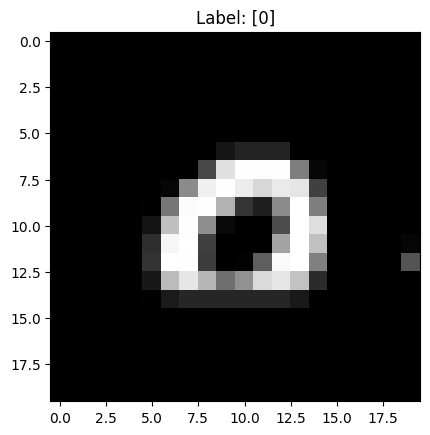

(20, 20)

In [117]:
image = X[0].reshape(20, 20)
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y[0]}")
plt.show()
image.shape

# Model 

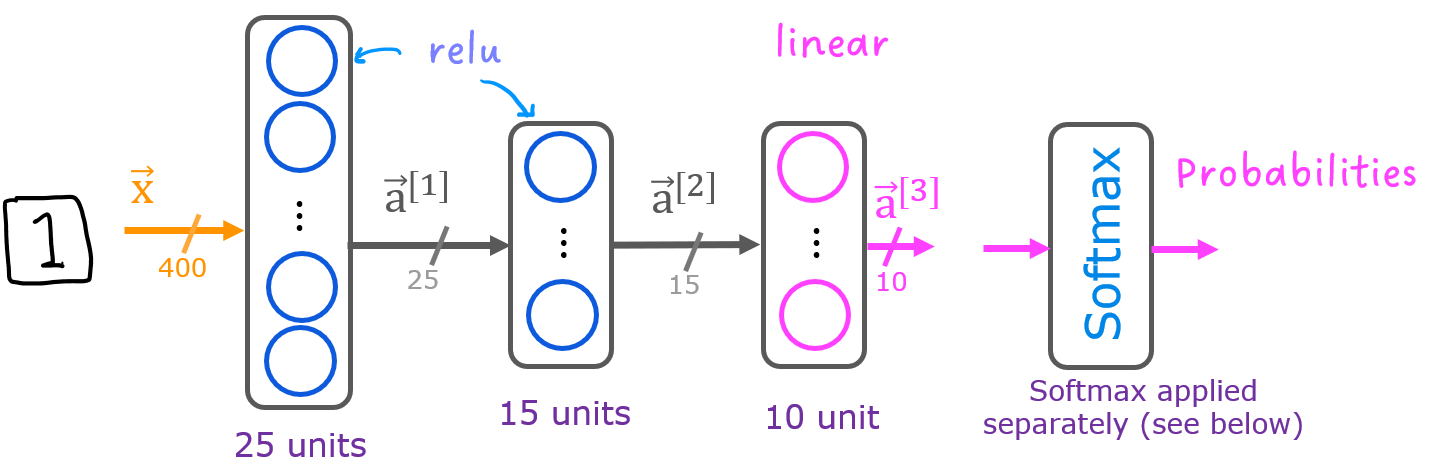

- Two dense layers with `relu` activations
- Output layer with `linear` activation
- our input is 20x20 pixels this gives us `(400,)`
---
- The parameters have dimensions that are sized for a neural network with $25$ units in `layer 1`, $15$ units in `layer 2` and $10$ output units in `layer 3`, one for each digit.

  - If network has $s_{in}$ units in a layer and $s_{out}$ units in the next layer, then 
    - $W$ will be of dimension $s_{in} \times s_{out}$.
    - $b$ will be a vector with $s_{out}$ elements
  
- Therefore, the shapes of `W`, and `b`,  are 
  - layer1: The shape of `W1` is (400, 25) and the shape of `b1` is (25,)
  - layer2: The shape of `W2` is (25, 15) and the shape of `b2` is: (15,)
  - layer3: The shape of `W3` is (15, 10) and the shape of `b3` is: (10,)
>**Note:** The bias vector `b` could be represented as a 1-D (n,) or 2-D (n,1) array

---
# Tensorflow Model Implementation

In [118]:
model = Sequential(
    [
        tf.keras.Input(shape=(400,)),
        Dense(25,activation='relu'),
        Dense(15,activation='relu'),
        Dense(10,activation='linear')
    ],
)

In [119]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 25)                  │          10,025 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 15)                  │             390 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,575 (41.31 KB)

 Trainable params: 10,575 (41.31 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
W1,b1,W2,b2,W3,b3 = model.get_weights()

In [121]:
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


## The following code:
* defines a loss function, `SparseCategoricalCrossentropy` and indicates the softmax should be included with the  loss calculation by adding `from_logits=True`)
* defines an optimizer. A popular choice is Adaptive Moment `Adam`

In [122]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer =tf.keras.optimizers.Adam(learning_rate=0.001),
)

model.fit(
    X,y,
    epochs = 40
)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 1.6599
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 0.7026
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - loss: 0.4787
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 0.3953
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - loss: 0.3480
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - loss: 0.3178
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - loss: 0.2892
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 0.2656
Epoch 9/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 938us/step - loss: 0.2504
Epoch 10/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 0.2347
Epoch 11/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - loss: 0.2178
Epoch 12/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.2075
Epoch 13/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - loss: 0.1936
Epoch 14/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - loss: 0.1872
Epoch 15/40
157/157 ━━━━━━━━━

# Prediction
- `prediction` raw model outputs before softmax — can be large negative numbers to large positive numbers
- `p`  probabilities

`np.argmax()` returns the index of the highest probability

In [123]:
prediction = model.predict(X[0].reshape(1,400))
print(prediction) # raw output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[ 3.080295   -9.37541    -2.8558218  -3.8142703   2.1836674   0.36556312
   2.6012874  -0.99219215 -5.269667   -4.5310836 ]]


In [124]:
print(f"predicting a zero {np.argmax(prediction)}")

predicting a zero 0


In [125]:
p = my_softmax(prediction) # prob

In [126]:
yhat = np.argmax(p)
print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 0


In [127]:
print(f" predicting a zero Probability vector: \n{p}\n")
print(f"Total of predictions: {np.sum(p)}")

 predicting a zero Probability vector: 
[[4.7281569e-01 1.8418219e-06 1.2493064e-03 4.7909326e-04 1.9288187e-01
  3.1311132e-02 2.9286095e-01 8.0543989e-03 1.1177620e-04 2.3394413e-04]]

Total of predictions: 1.0


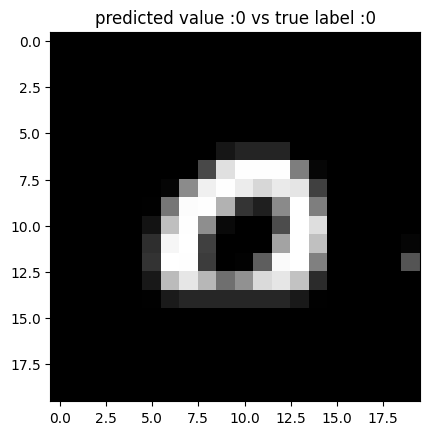

(20, 20)

In [128]:
image = X[0].reshape(20, 20)
plt.imshow(image, cmap='gray')
plt.title(f"predicted value :{np.argmax(prediction)} vs true label :{y[0,0]}")
plt.show()
image.shape

# predicting 5

In [129]:
prediction2 = model.predict(X[1].reshape(1,400)) # raw output before sotfmax
print(prediction2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[ -2.0259902 -18.255331   -9.463323   -5.142315   -5.179685    5.2491074
   -3.6216555 -11.776945   -2.9926171  -8.360703 ]]


In [130]:
p2 = my_softmax(prediction2) # probabilities

In [131]:
y_hat2 = np.argmax(p2) 
y_hat2

5

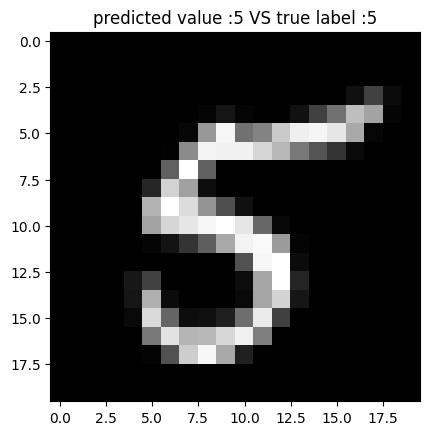

(20, 20)

In [132]:
image = X[1].reshape(20, 20)
plt.imshow(image, cmap='gray')
plt.title(f"predicted value :{y_hat2} VS true label :{y[1,0]}")
plt.show()
image.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

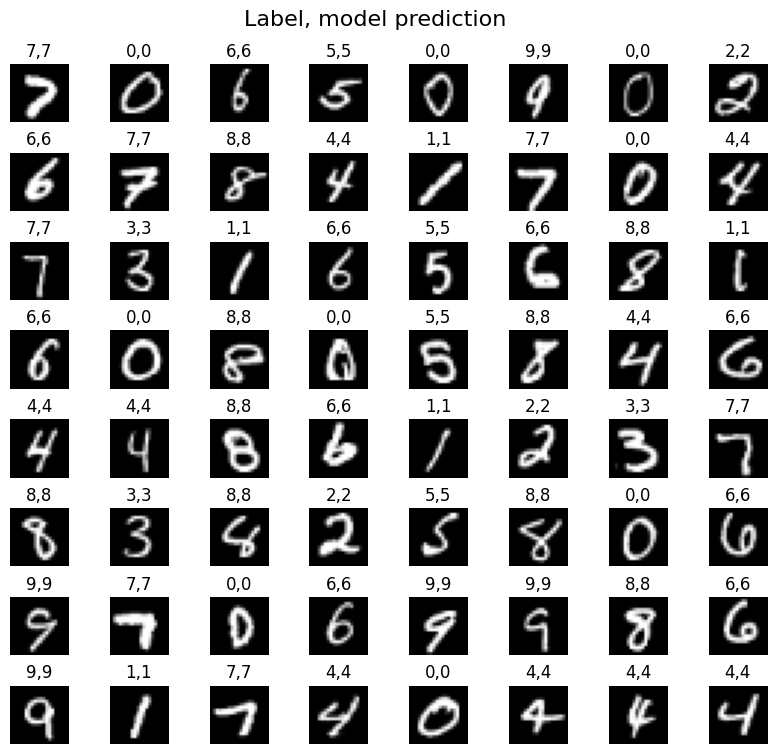

In [133]:
m,n = X.shape
fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92])

for i,ax in enumerate(axes.flat):
    random_index = np.random.randint(m)

    X_random_res = X[random_index].reshape((20,20))

    ax.imshow(X_random_res,cmap='gray')

    predictions = my_softmax(model.predict(X[random_index].reshape(1,400)))
    predictions = np.argmax(predictions)

    ax.set_title(f"{y[random_index,0]},{predictions}")
    ax.set_axis_off()
fig.suptitle("Label, model prediction", fontsize=16)
plt.show()